In [1]:
import numpy as np
import bokeh
import dpluspy
import pickle 
import matplotlib.pyplot as plt 
import matplotlib

In [18]:
L = 0
u_sum = 0

for ii in range(1, 23):
    positions = dpluspy.utils._read_bed_file_positions(
        f"simulation/data/bed_files/filterbed_1e-4M_exon_buffer/mask_chr{ii}.bed.gz") + 1
    mutmap = dpluspy.parsing._load_mutation_map(
        f"simulation/data/mutation_maps/scaled_roulette_b37_10kb/roulette_10kb_chr{ii}.csv.gz", positions)
    L += len(positions)
    u_sum += np.sum(mutmap)

print(u_sum / L)

1.299999766318508e-08


In [27]:
graph = "simulation/full_model.yaml"
control = dpluspy.inference.load_stats(
    "simulation/trials/heterog_u_0_rep_0_naive_stats.pkl", return_dict=True)
naive = dpluspy.inference.load_stats(
    "simulation/trials/heterog_u_1_rep_0_naive_stats.pkl", return_dict=True)
weighted = dpluspy.inference.load_stats(
    "simulation/trials/heterog_u_1_rep_0_weighted_stats.pkl", return_dict=True)
model = dpluspy.inference.compute_bin_stats(
    graph, sampled_demes=control["pop_ids"], u=1.15e-8, bins=control["bins"])

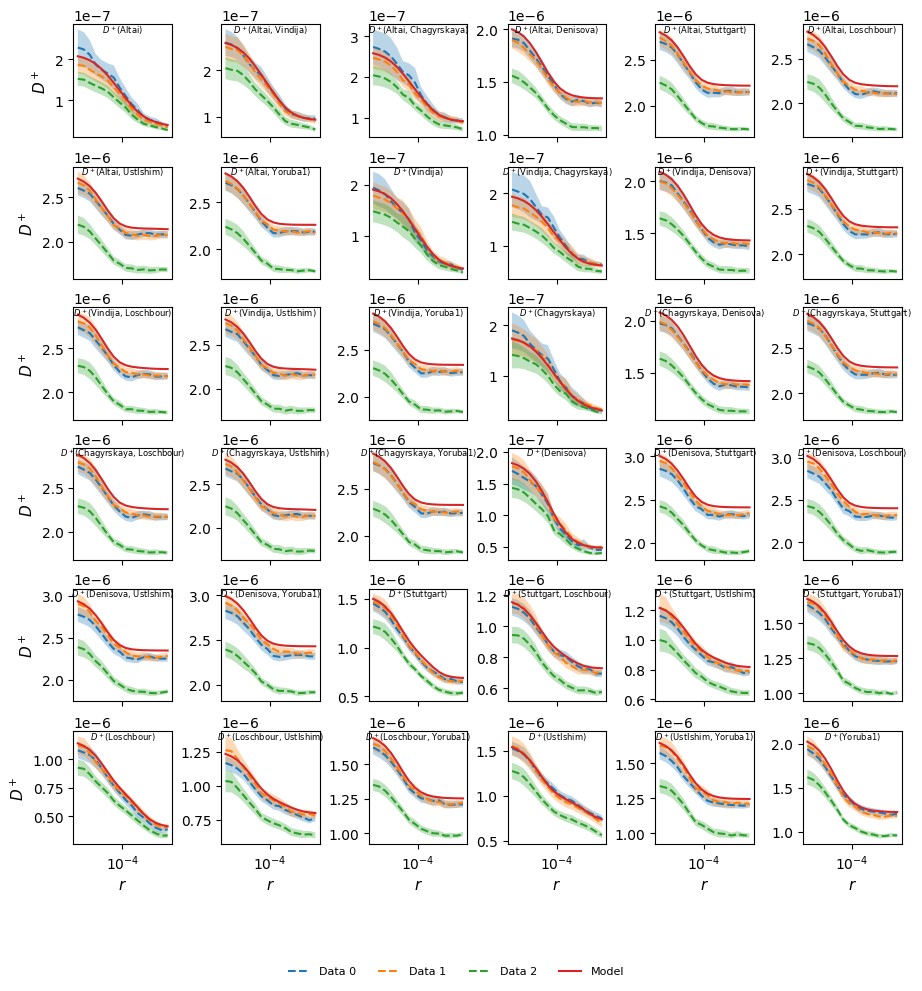

In [5]:
dpluspy.plotting.plot_D_plus_curves(
    models=[model],
    means=[control["means"], naive["means"], weighted["means"]],
    varcovs=[control["varcovs"], naive["varcovs"], weighted["varcovs"]],
    bins=weighted["bins"],
    pop_ids=weighted["pop_ids"],
    cols=6,
    ax_size=1.5
)

In [24]:
control_reps = []
naive_reps = []
weighted_reps = []

for ii in range(5, 10):
    pop_ids, bins, means, varcovs = dpluspy.inference.load_stats(
        f"simulation/trials/heterog_u_0_rep_{ii}_naive_stats.pkl")
    control_reps.append(means)
    pop_ids, bins, means, varcovs = dpluspy.inference.load_stats(
        f"simulation/trials/heterog_u_1_rep_{ii}_naive_stats.pkl")
    naive_reps.append(means)
    pop_ids, bins, means, varcovs = dpluspy.inference.load_stats(
        f"simulation/trials/heterog_u_1_rep_{ii}_weighted_stats.pkl")
    weighted_reps.append(means)

In [25]:
control_reps = np.array(control_reps)
naive_reps = np.array(naive_reps)
weighted_reps = np.array(weighted_reps)

control_mean = [x for x in np.mean(control_reps, axis=0)]
naive_mean = [x for x in np.mean(naive_reps, axis=0)]
weighted_mean = [x for x in np.mean(weighted_reps, axis=0)]

control_var = [np.cov(control_reps[:, i], rowvar=False) for i in range(len(bins))]
naive_var = [np.cov(naive_reps[:, i], rowvar=False) for i in range(len(bins))]
weighted_var = [np.cov(weighted_reps[:, i], rowvar=False) for i in range(len(bins))]

with open("naive_sims_100_reps_mean.pkl", "wb") as fout:
    data = {"bins": bins, "pop_ids": pop_ids, "means": naive_mean,
            "varcovs": naive_var}
    pickle.dump(data, fout)

with open("weighted_sims_100_reps_mean.pkl", "wb") as fout:
    data = {"bins": bins, "pop_ids": pop_ids, "means": weighted_mean,
            "varcovs": weighted_var}
    pickle.dump(data, fout)

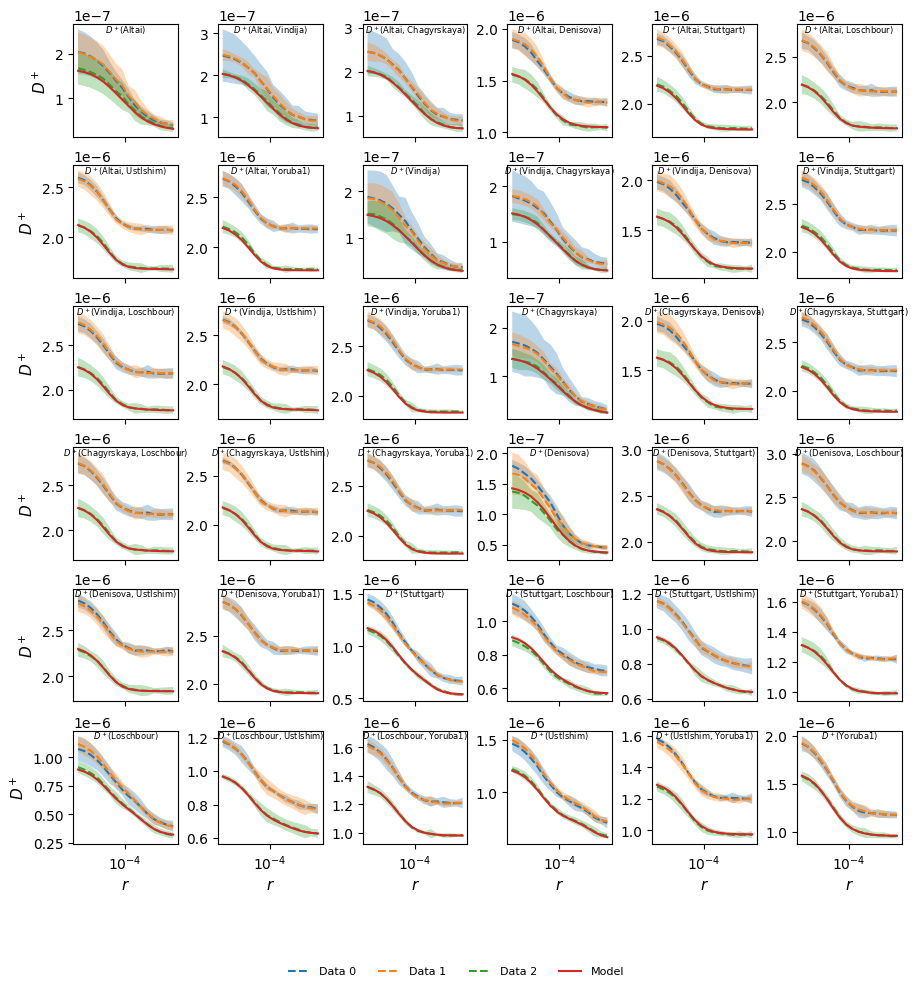

In [28]:
dpluspy.plotting.plot_D_plus_curves(
    models=[model],
    means=[control_mean, naive_mean, weighted_mean],
    varcovs=[control_var, naive_var, weighted_var],
    bins=bins,
    pop_ids=pop_ids,
    cols=6,
    ax_size=1.5
)